In [1]:
WANDB_API_KEY = "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" 
WANDB_ENTITY  = "kirill456z"
WANDB_PROJECT = "physics4llm"

In [2]:
RUN_IDS = {
    # 5 seeds per (arch, size); averaged before plotting
    "llama": [
        # 3m — seeds 54, 55, 56, 57, 58
        "scaling_law_exps_3_llama_3m_0.4.84",
        "remaining_runs_llama_3m_seed_55_0.4.134",
        "remaining_runs_llama_3m_seed_56_0.4.135",
        "scaling_law_4_more_seeds_llama_3m_seed_57_0.4.160",
        "scaling_law_4_more_seeds_llama_3m_seed_58_0.4.161",
        # 10m — seeds 54, 55, 56, 57, 58
        "scaling_law_exps_3_llama_10m_0.4.82",
        "remaining_runs_llama_10m_seed_55_0.4.132",
        "remaining_runs_llama_10m_seed_56_0.4.133",
        "scaling_law_4_more_seeds_llama_10m_seed_57_0.4.156",
        "scaling_law_4_more_seeds_llama_10m_seed_58_0.4.157",
        # 30m — seeds 52, 55, 56, 57, 58
        "scaling_law_exps_3_llama_30m_0.4.83",
        "depo_variance_impact_investigation_2_all_tasks_seed_55_0.4.120",
        "depo_variance_impact_investigation_2_all_tasks_seed_56_0.4.121",
        "scaling_law_4_more_seeds_llama_30m_seed_57_0.4.158",
        "scaling_law_4_more_seeds_llama_30m_seed_58_0.4.159",
        # 100m — seeds 54, 55, 56, 57, 58
        "scaling_law_exps_3_llama_100m_0.4.81",
        "seed_variance_comp_llama_seed_55_0.4.99",
        "seed_variance_comp_llama_seed_56_0.4.100",
        "scaling_law_4_more_seeds_llama_100m_seed_57_0.4.154",
        "scaling_law_4_more_seeds_llama_100m_seed_58_0.4.155",
    ],
    "canon": [
        # 3m — seeds 54, 55, 56, 57, 58
        "scaling_law_exps_3_canon_3m_0.4.80",
        "remaining_runs_canon_3m_seed_55_0.4.130",
        "remaining_runs_canon_3m_seed_56_0.4.131",
        "scaling_law_4_more_seeds_canon_3m_seed_57_0.4.152",
        "scaling_law_4_more_seeds_canon_3m_seed_58_0.4.153",
        # 10m — seeds 54, 55, 56, 57, 58
        "scaling_law_exps_3_canon_10m_0.4.78",
        "remaining_runs_canon_10m_seed_55_0.4.126",
        "remaining_runs_canon_10m_seed_56_0.4.127",
        "scaling_law_4_more_seeds_canon_10m_seed_57_0.4.148",
        "scaling_law_4_more_seeds_canon_10m_seed_58_0.4.149",
        # 30m — seeds 52, 55, 56, 57, 58
        "scaling_law_exps_3_canon_30m_0.4.79",
        "remaining_runs_canon_30m_seed_55_0.4.128",
        "remaining_runs_canon_30m_seed_56_0.4.129",
        "scaling_law_4_more_seeds_canon_30m_seed_57_0.4.150",
        "scaling_law_4_more_seeds_canon_30m_seed_58_0.4.151",
        # 100m — seeds 54, 55, 56, 57, 58
        "scaling_law_exps_3_canon_100m_0.4.77",
        "canon_seed_variance_100m_canon_3e-4_seed_55_0.4.118",
        "canon_seed_variance_100m_canon_3e-4_seed_56_0.4.119",
        "scaling_law_4_more_seeds_canon_100m_seed_57_0.4.146",
        "scaling_law_4_more_seeds_canon_100m_seed_58_0.4.147",
    ],
}

In [3]:
from utils import TASK_NAMES, get_wandb_metric_keys, fetch_runs_results, debug_run_summary, plot_scaling_law, plot_custom_metric, plot_task_metrics_grid, plot_all_tasks_primary_metrics


In [4]:
SELECTED_TASKS = TASK_NAMES
METRIC_KEYS = get_wandb_metric_keys(SELECTED_TASKS)

print(f"Fetching {len(METRIC_KEYS)} metric keys:")
for k in METRIC_KEYS:
    print(" ", k)

Fetching 25 metric keys:
  loss/out
  evals/synthetic/concomp_factor_edges_list/accuracy
  evals/synthetic/concomp_factor_edges_list/prefix_accuracy
  evals/synthetic/concomp_factor_edges_list/component_recall
  evals/synthetic/concomp_factor_adj_list/accuracy
  evals/synthetic/concomp_factor_adj_list/prefix_accuracy
  evals/synthetic/concomp_factor_adj_list/component_recall
  evals/synthetic/depo_edges_list/hop_1/accuracy
  evals/synthetic/depo_edges_list/hop_2/accuracy
  evals/synthetic/depo_edges_list/hop_4/accuracy
  evals/synthetic/depo_edges_list/hop_8/accuracy
  evals/synthetic/depo_adj_list/hop_1/accuracy
  evals/synthetic/depo_adj_list/hop_2/accuracy
  evals/synthetic/depo_adj_list/hop_4/accuracy
  evals/synthetic/depo_adj_list/hop_8/accuracy
  evals/synthetic/shortest_path_edges_list/set_accuracy
  evals/synthetic/shortest_path_edges_list/prefix_accuracy
  evals/synthetic/shortest_path_edges_list/is_correct_path
  evals/synthetic/shortest_path_adj_list/set_accuracy
  evals/sy

In [5]:
results_df = fetch_runs_results(
    run_ids=RUN_IDS,
    api_key=WANDB_API_KEY,
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
)

print(f"\nFetched {len(results_df)} runs")
cols = [c for c in ["label", "run_name", "n_params"] if c in results_df.columns]
results_df[cols]


[llama]
  loss/out = 0.4052  (avg of last 100 steps)
  scaling_law_exps_3_llama_3m_0.4.84        n_params=   3,280,896
  loss/out = 0.3778  (avg of last 100 steps)
  remaining_runs_llama_3m_seed_55_0.4.134   n_params=   3,280,896
  loss/out = 0.4115  (avg of last 100 steps)
  remaining_runs_llama_3m_seed_56_0.4.135   n_params=   3,280,896
  loss/out = 0.4232  (avg of last 100 steps)
  scaling_law_4_more_seeds_llama_3m_seed_57_0.4.160  n_params=   3,280,896
  loss/out = 0.4130  (avg of last 100 steps)
  scaling_law_4_more_seeds_llama_3m_seed_58_0.4.161  n_params=   3,280,896
  loss/out = 0.2599  (avg of last 100 steps)
  scaling_law_exps_3_llama_10m_0.4.82       n_params=  10,822,656
  loss/out = 0.2650  (avg of last 100 steps)
  remaining_runs_llama_10m_seed_55_0.4.132  n_params=  10,822,656
  loss/out = 0.2626  (avg of last 100 steps)
  remaining_runs_llama_10m_seed_56_0.4.133  n_params=  10,822,656
  loss/out = 0.2408  (avg of last 100 steps)
  scaling_law_4_more_seeds_llama_10m_see

,label,run_name,n_params
0,llama,scaling_law_exps_3_llama_3m_0.4.84,3280896
1,llama,remaining_runs_llama_3m_seed_55_0.4.134,3280896
2,llama,remaining_runs_llama_3m_seed_56_0.4.135,3280896
3,llama,scaling_law_4_more_seeds_llama_3m_seed_57_0.4.160,3280896
4,llama,scaling_law_4_more_seeds_llama_3m_seed_58_0.4.161,3280896
5,llama,scaling_law_exps_3_llama_10m_0.4.82,10822656
6,llama,remaining_runs_llama_10m_seed_55_0.4.132,10822656
7,llama,remaining_runs_llama_10m_seed_56_0.4.133,10822656
8,llama,scaling_law_4_more_seeds_llama_10m_seed_57_0.4...,10822656
9,llama,scaling_law_4_more_seeds_llama_10m_seed_58_0.4...,10822656


In [6]:
## Average over seeds (3 per arch × size) → one row per (label, n_params)
_id_cols = {c for c in results_df.columns if c in {"run_id", "run_name", "label", "n_params"}}
_metric_cols = [c for c in results_df.columns if c not in _id_cols]
_group_cols = [c for c in ["label", "n_params"] if c in results_df.columns]

results_df = results_df.groupby(_group_cols, as_index=False)[_metric_cols].mean(numeric_only=True)
print(f"Averaged to {len(results_df)} rows (one per arch × size)")
results_df[_group_cols]

Averaged to 8 rows (one per arch × size)


,label,n_params
0,canon,3309568
1,canon,10887168
2,canon,25559040
3,canon,85622784
4,llama,3280896
5,llama,10822656
6,llama,25444352
7,llama,85364736


In [7]:
meta_cols = {"run_id", "run_name", "n_params"}
metric_cols = [c for c in results_df.columns if c not in meta_cols]
print(f"Runs: {len(results_df)}  |  Metric columns: {len(metric_cols)}")
for c in metric_cols:
    non_null = results_df[c].notna().sum()
    print(f"  {c:<60s}  {non_null:>3}/{len(results_df)} runs")

Runs: 8  |  Metric columns: 75
  label                                                           8/8 runs
  _runtime                                                        8/8 runs
  _step                                                           8/8 runs
  _timestamp                                                      8/8 runs
  acc_step                                                        8/8 runs
  evals/synthetic/bfs_adj_list/has_eos                            8/8 runs
  evals/synthetic/bfs_adj_list/prefix_accuracy                    8/8 runs
  evals/synthetic/bfs_adj_list/set_precision                      8/8 runs
  evals/synthetic/bfs_adj_list/set_recall                         8/8 runs
  evals/synthetic/bfs_edges_list/has_eos                          8/8 runs
  evals/synthetic/bfs_edges_list/prefix_accuracy                  8/8 runs
  evals/synthetic/bfs_edges_list/set_precision                    8/8 runs
  evals/synthetic/bfs_edges_list/set_recall                       8/8

In [8]:
results_df

,label,n_params,_runtime,_step,_timestamp,acc_step,evals/synthetic/bfs_adj_list/has_eos,evals/synthetic/bfs_adj_list/prefix_accuracy,evals/synthetic/bfs_adj_list/set_precision,evals/synthetic/bfs_adj_list/set_recall,...,memory/num_alloc_retries,memory/num_ooms,memory/power_draw,optim/grad_norm,optim/lr,optim/total_tokens,speed/FLOPS,speed/curr_iter_time,speed/data_load_time,speed/wps
0,canon,3309568,8484.635462,80000.0,1.779606e+09,0.0,1.0,0.730942,0.855611,0.858170,...,0.0,0.0,217271.8,1.092190,0.000030,1.048576e+10,3.425476e+13,0.07570,0.04004,1.187017e+06
1,canon,10887168,13475.185638,80000.0,1.779613e+09,0.0,1.0,0.845589,0.919800,0.922261,...,0.0,0.0,296983.4,0.591185,0.000030,1.048576e+10,5.488584e+13,0.15640,0.03580,6.693635e+05
2,canon,25559040,21978.842955,80000.0,1.779763e+09,0.0,1.0,0.915843,0.959600,0.959814,...,0.0,0.0,351398.6,0.676112,0.000030,1.048550e+10,8.052140e+13,0.28752,0.03062,4.115702e+05
3,canon,85622784,56166.889335,73362.0,1.779587e+09,0.0,1.0,0.921400,0.959196,0.960200,...,0.0,0.0,367000.2,0.275850,0.000031,9.615704e+09,1.049530e+14,0.69036,0.04004,1.808198e+05
4,llama,3280896,8461.977626,80000.0,1.779612e+09,0.0,1.0,0.565939,0.722965,0.719059,...,0.0,0.0,150391.4,0.723303,0.000030,1.048576e+10,4.107145e+13,0.04328,0.04986,1.436692e+06
5,llama,10822656,10170.688410,80000.0,1.779612e+09,0.0,1.0,0.766498,0.864753,0.868687,...,0.0,0.0,167007.6,0.607138,0.000030,1.048576e+10,8.478557e+13,0.08524,0.04000,1.041263e+06
6,llama,25444352,13266.277464,80000.0,1.779588e+09,0.0,1.0,0.927183,0.965556,0.966956,...,0.0,0.0,313721.4,0.302026,0.000030,1.048576e+10,1.254375e+14,0.17168,0.03228,6.447139e+05
7,llama,85364736,36672.226695,71632.0,1.779485e+09,0.0,1.0,0.928628,0.966378,0.967878,...,0.0,0.0,389065.2,0.214411,0.000039,9.388950e+09,1.499354e+14,0.44846,0.09004,2.593398e+05


## Loss

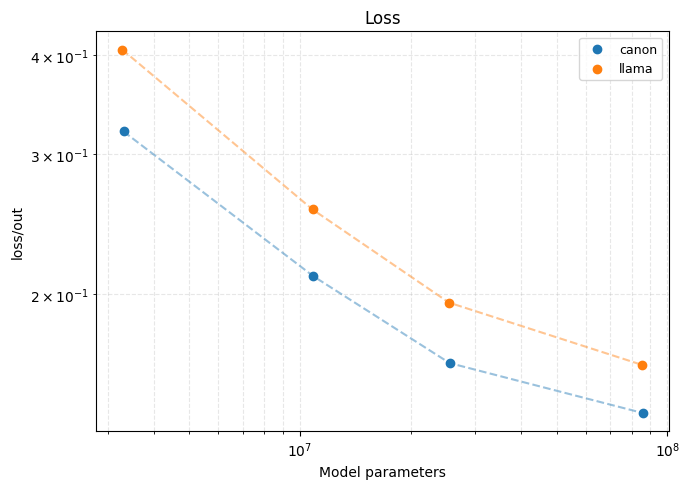

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
plot_scaling_law(
    results_df=results_df,
    metric_key="loss/out",
    ax=ax,
    log_x=True,
    log_y=True,
    title="Loss",
)
plt.tight_layout()
plt.show()

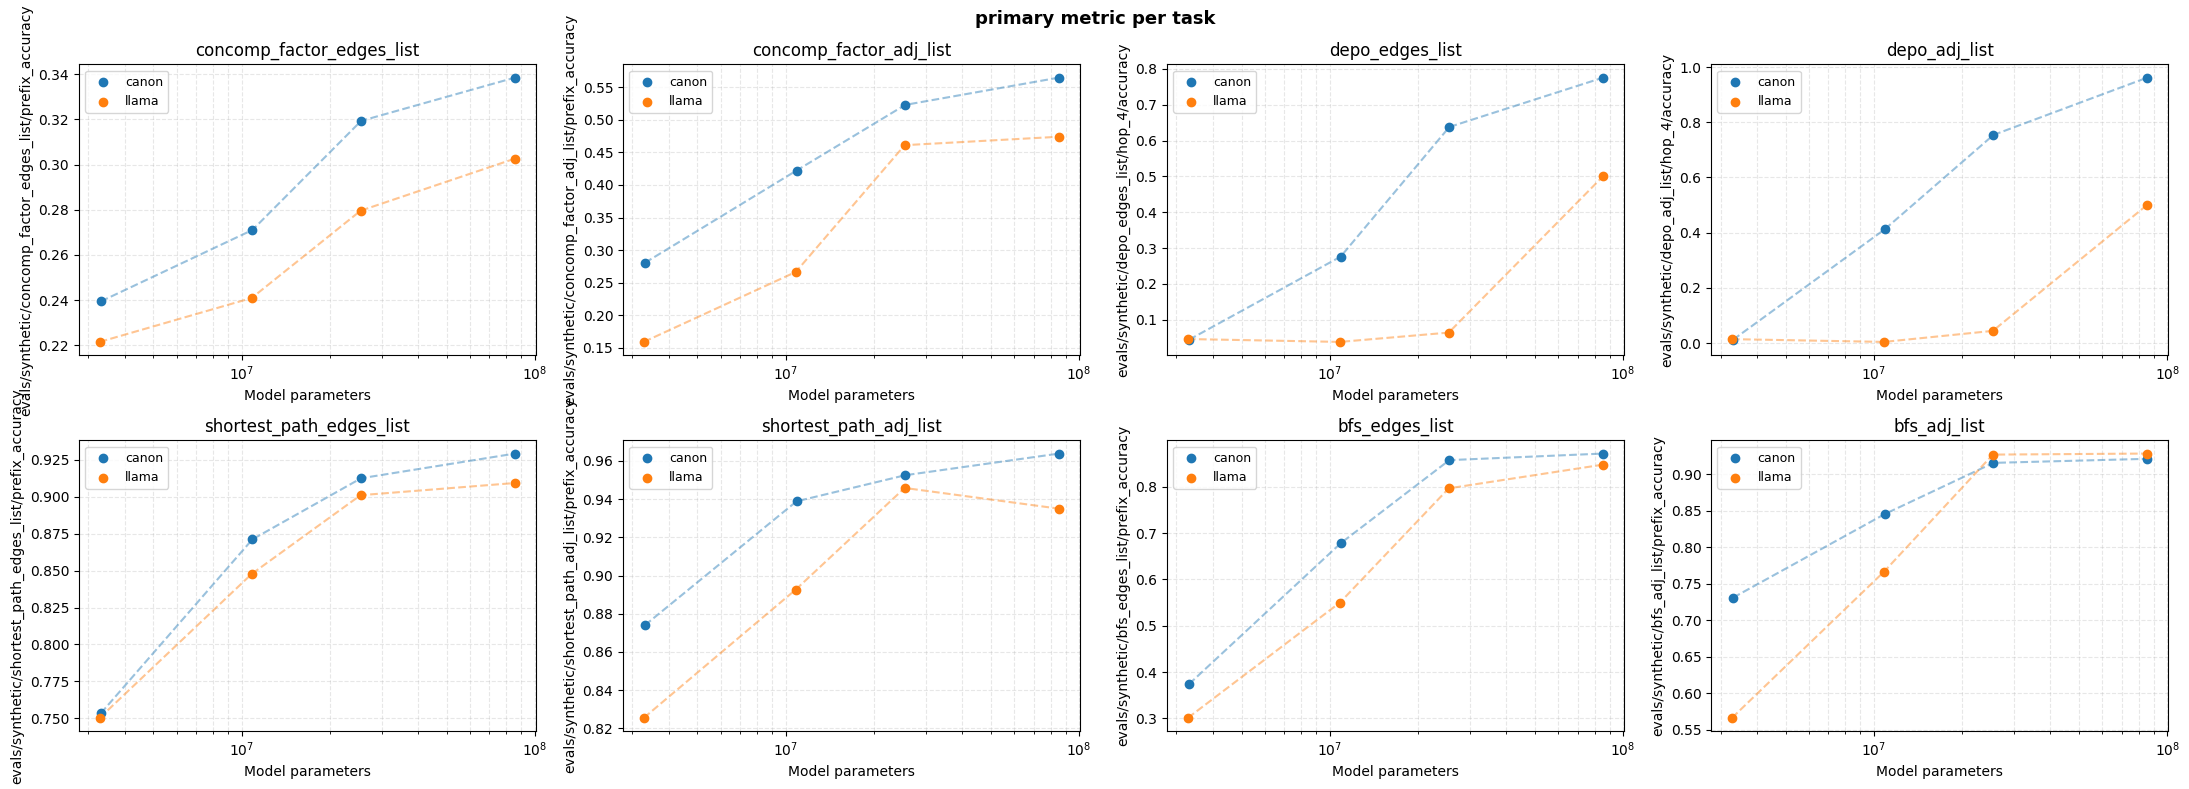

In [10]:
fig = plot_all_tasks_primary_metrics(
    results_df=results_df,
    task_names=SELECTED_TASKS,
    log_x=True,
    log_y=False,
)
plt.show()

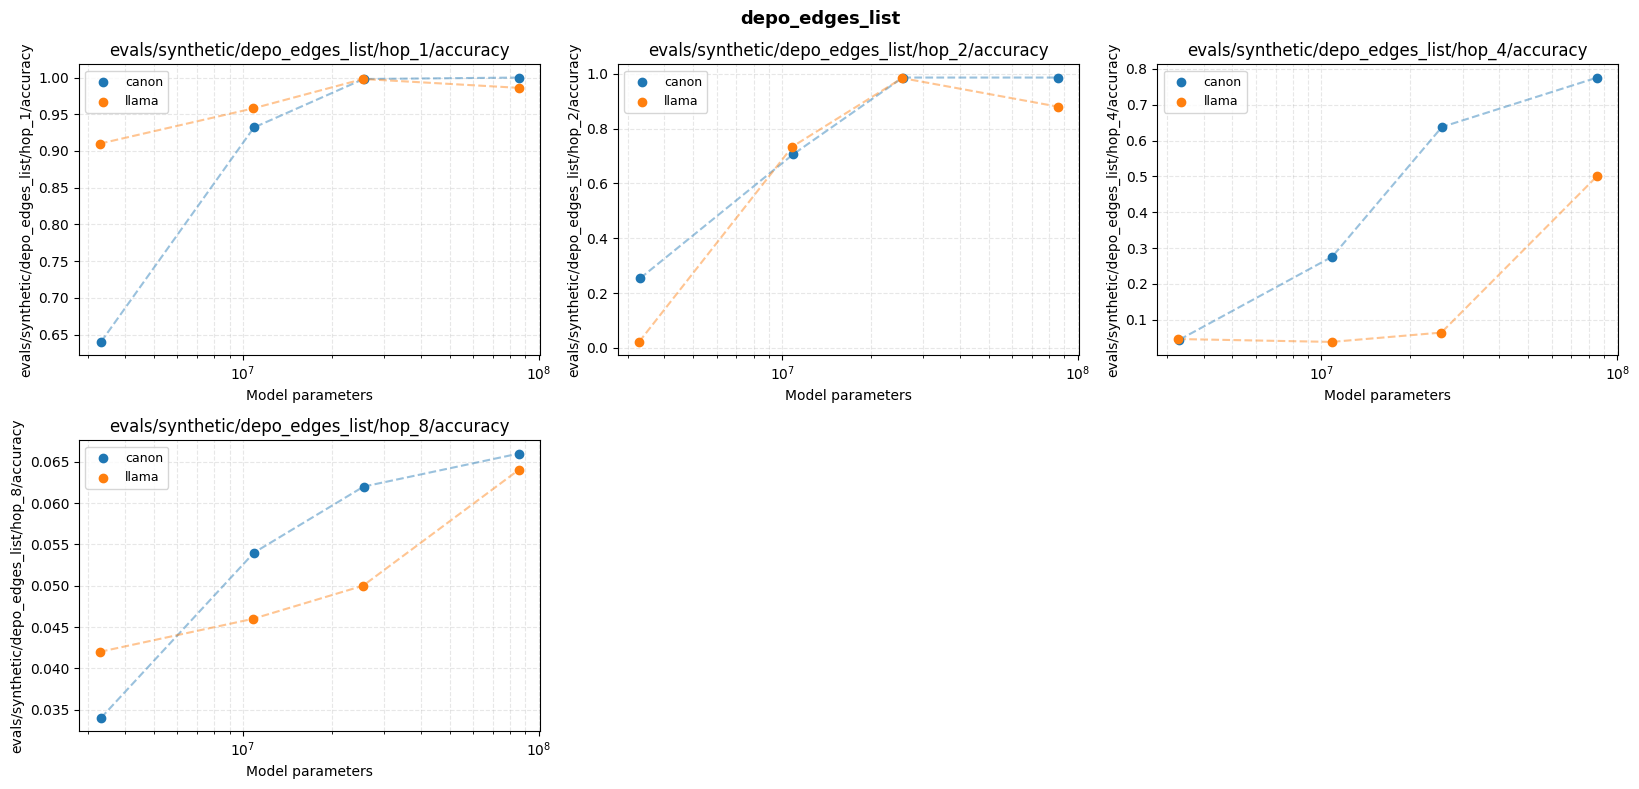

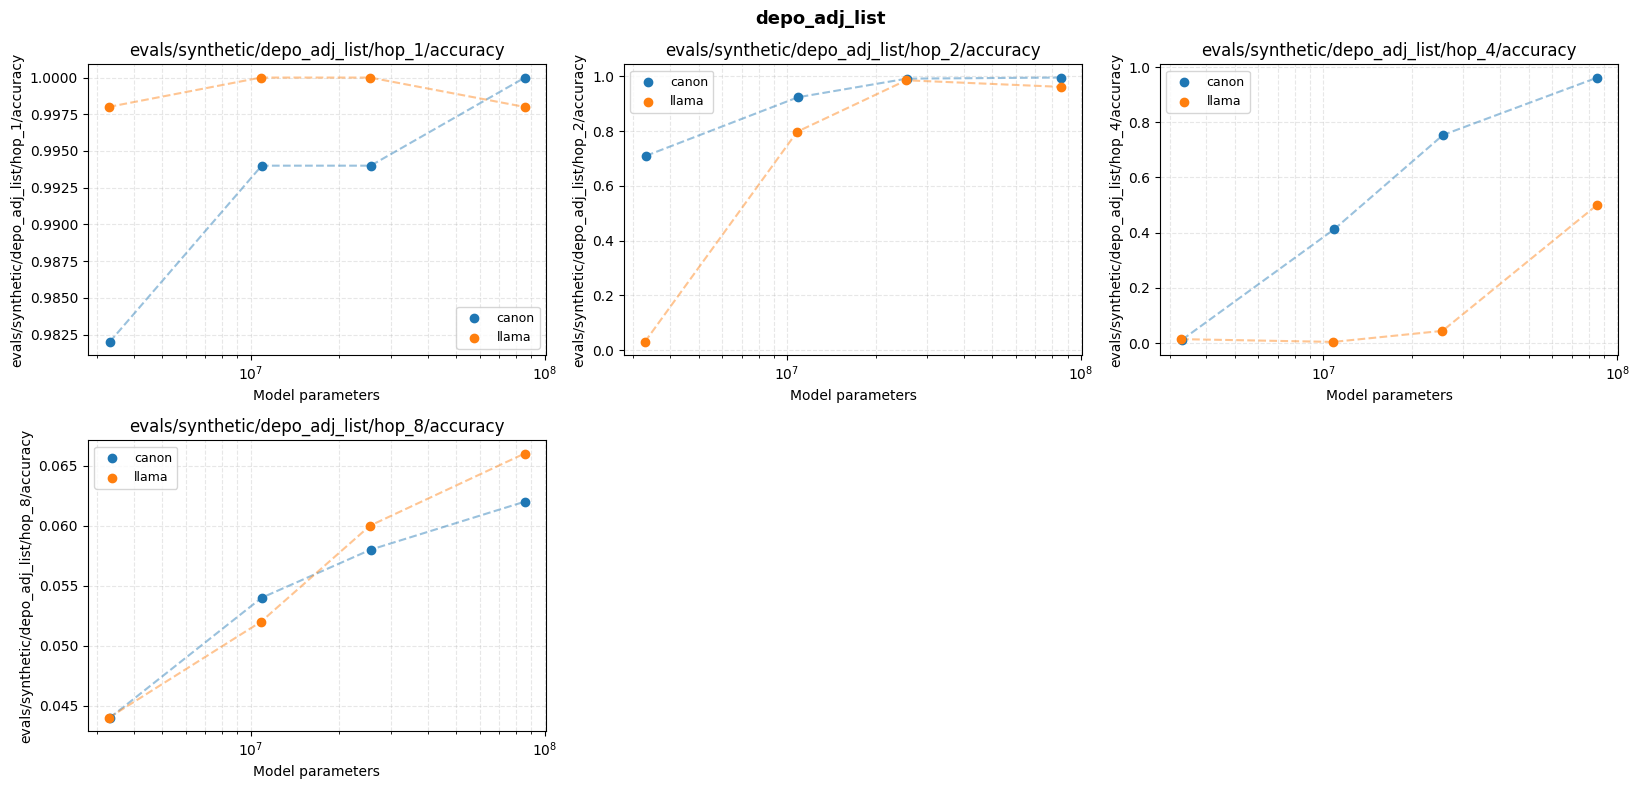

In [11]:
# Depo — all hop levels
for task in ["depo_edges_list", "depo_adj_list"]:
    fig = plot_task_metrics_grid(
        results_df=results_df,
        task_name=task,
        log_x=True,
        log_y=False,
    )
    plt.show()

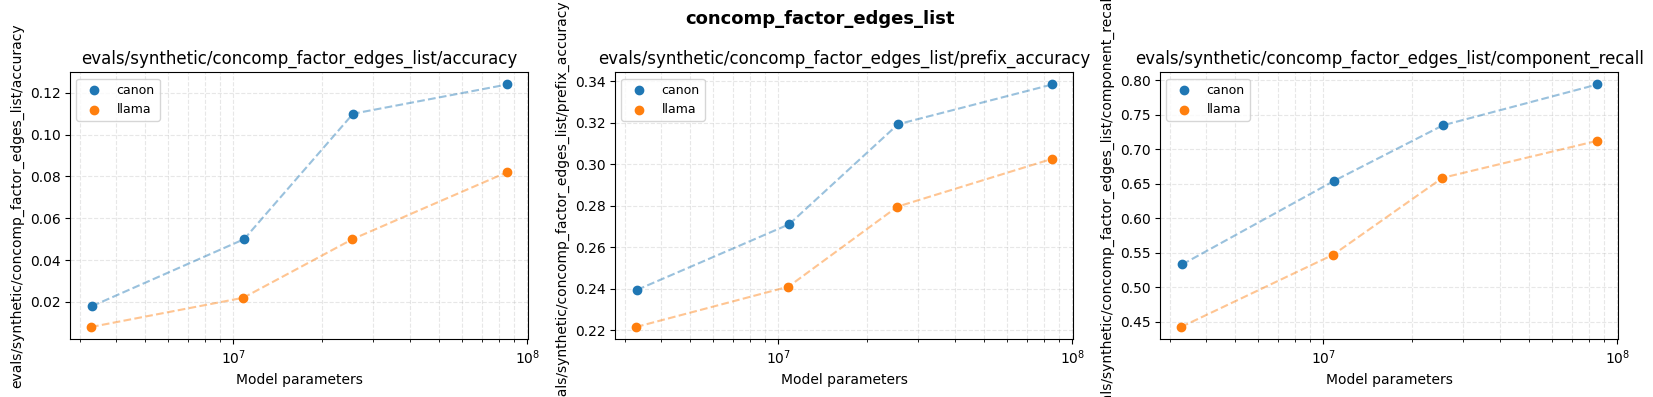

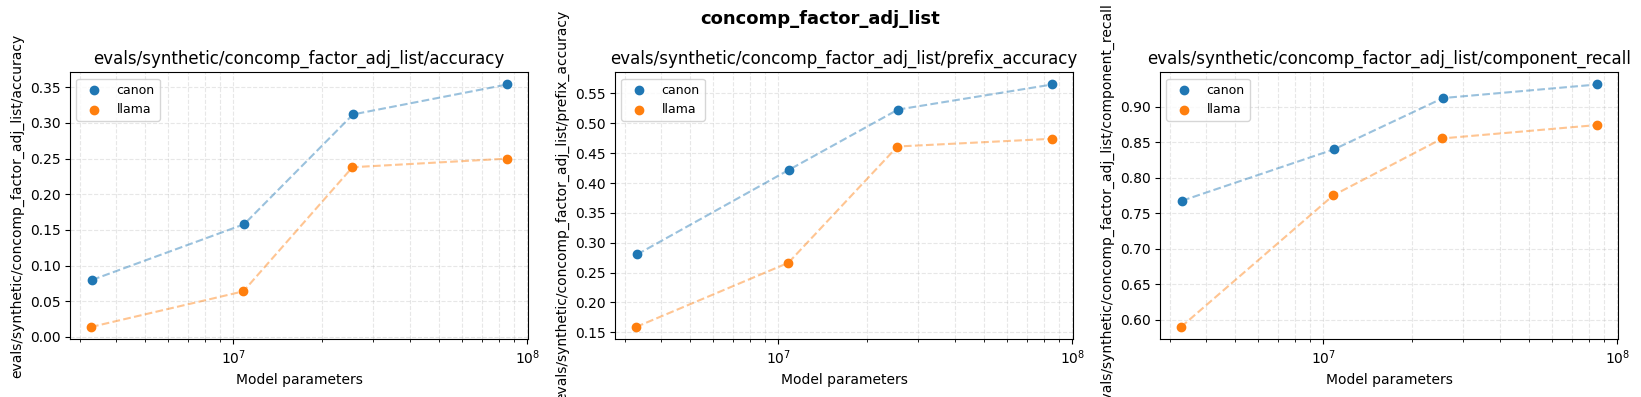

In [12]:
for task in ["concomp_factor_edges_list", "concomp_factor_adj_list"]:
    fig = plot_task_metrics_grid(
        results_df=results_df,
        task_name=task,
        log_x=True,
        log_y=False,
    )
    plt.show()

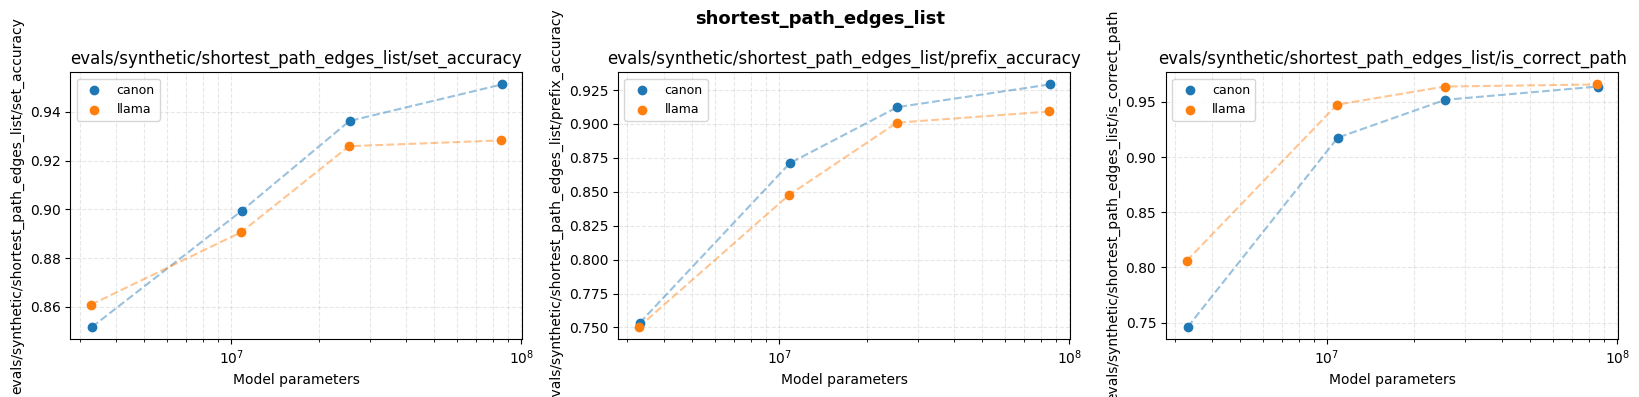

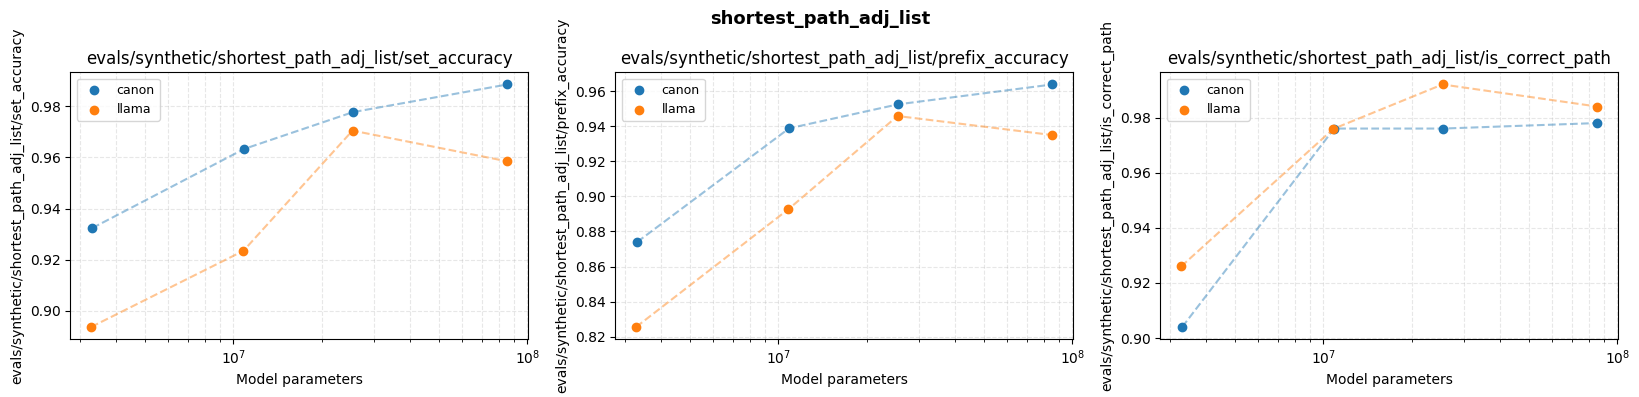

In [13]:
for task in ["shortest_path_edges_list", "shortest_path_adj_list"]:
    fig = plot_task_metrics_grid(
        results_df=results_df,
        task_name=task,
        log_x=True,
        log_y=False,
    )
    plt.show()

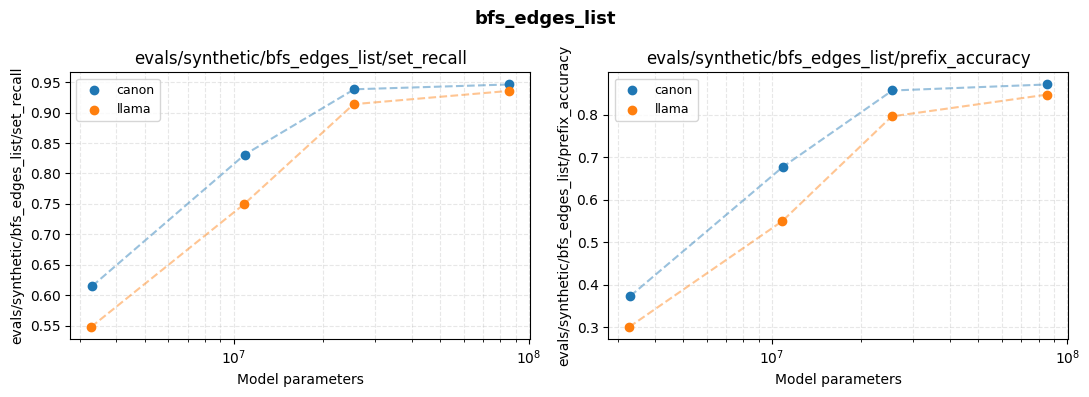

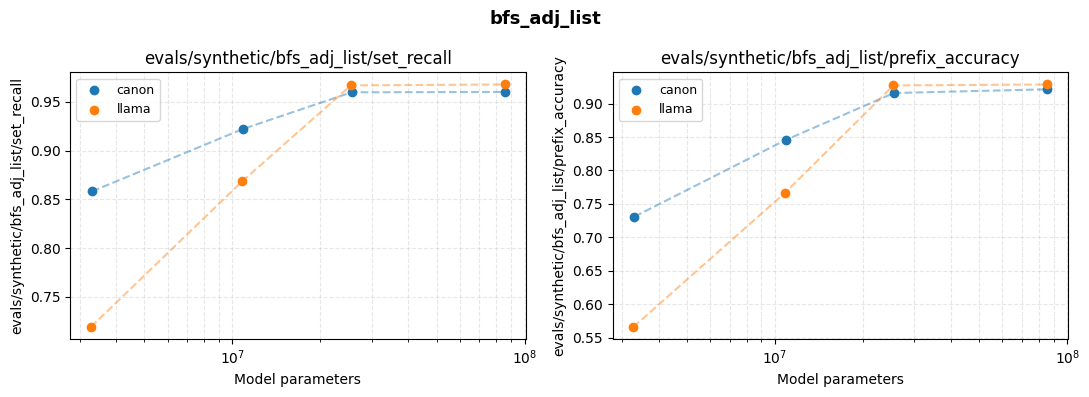

In [14]:
for task in ["bfs_edges_list", "bfs_adj_list"]:
    fig = plot_task_metrics_grid(
        results_df=results_df,
        task_name=task,
        log_x=True,
        log_y=False,
    )
    plt.show()

In [15]:
metric_keys = ['evals/synthetic/concomp_factor_edges_list/prefix_accuracy',
 'evals/synthetic/concomp_factor_adj_list/prefix_accuracy',
 'evals/synthetic/shortest_path_edges_list/prefix_accuracy',
 'evals/synthetic/shortest_path_adj_list/prefix_accuracy',
 'evals/synthetic/bfs_edges_list/prefix_accuracy',
 'evals/synthetic/bfs_adj_list/prefix_accuracy']

Averaging 8/8 primary metrics:
  evals/synthetic/depo_edges_list/hop_4/accuracy
  evals/synthetic/depo_adj_list/hop_4/accuracy
  evals/synthetic/concomp_factor_edges_list/prefix_accuracy
  evals/synthetic/concomp_factor_adj_list/prefix_accuracy
  evals/synthetic/shortest_path_edges_list/prefix_accuracy
  evals/synthetic/shortest_path_adj_list/prefix_accuracy
  evals/synthetic/bfs_edges_list/prefix_accuracy
  evals/synthetic/bfs_adj_list/prefix_accuracy


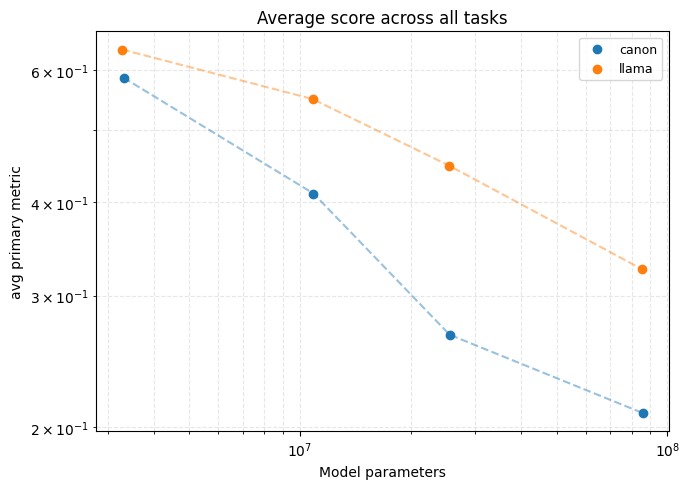

In [16]:
from utils import plot_custom_metric, wandb_eval_key, TASK_PRIMARY_METRIC

primary_keys = [
    wandb_eval_key(task, metric)
    for task, metric in TASK_PRIMARY_METRIC.items()
]
available_keys = [k for k in primary_keys if k in results_df.columns]
print(f"Averaging {len(available_keys)}/{len(primary_keys)} primary metrics:")
for k in available_keys:
    print(f"  {k}")

results_df["avg_primary_metric"] = results_df[available_keys].mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
plot_custom_metric(
    results_df=results_df,
    metric_values=1 - results_df["avg_primary_metric"],
    metric_name="avg primary metric",
    ax=ax,
    log_x=True,
    log_y=True,
    title="Average score across all tasks",
)
plt.tight_layout()
plt.show()

### Notes
- sweep LRs
- Leave out depo of the training
- try narrow llama on depo

In [ ]:
Notes
- Add canon to 14 layer 
- Try more layers / compare how many layer canon "adds"